<a href="https://colab.research.google.com/github/arulperiyannagounder-collab/Training_Hands_on/blob/main/IMDB_dataset_analysis_using_BINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=200),
    Bidirectional(LSTM(64)),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [5]:
h = model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 116s 708ms/step - accuracy: 0.7362 - loss: 0.5144 - val_accuracy: 0.8534 - val_loss: 0.3524
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 140s 697ms/step - accuracy: 0.8873 - loss: 0.2828 - val_accuracy: 0.8778 - val_loss: 0.3101
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 110s 695ms/step - accuracy: 0.9254 - loss: 0.1988 - val_accuracy: 0.8714 - val_loss: 0.3105


Text(0.5, 1.0, 'Accuracy  vs  Validation Accuracy')

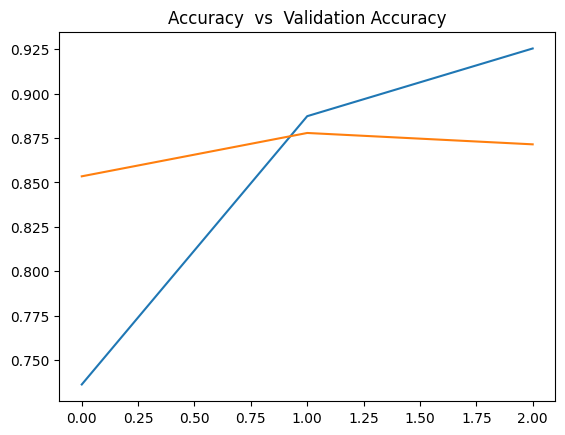

In [9]:
import matplotlib.pyplot as plt
plt.plot(h.history['accuracy'])
plt.plot(h.history['val_accuracy'])
plt.title('Accuracy  vs  Validation Accuracy')